In [49]:
import pandas as pd
import os
from pathlib import Path
import datetime

# Classes

In [50]:
class Player():
    def __init__(self, id, name):
        self.id = id
        self.name = name

        self.elo_rating = 1200
        self.elo_rank: int = None
        self.elo_history = {}  # Dict to store ranking history: {tourney_date: ranking aftermatch}

        #Surface elo ratings and ranks
        self.elo_surf_rating = {'Hard': 1200, 'Clay': 1200, 'Carpet': 1200, 'Grass': 1200, 'Unknown': 1200}
        self.elo_surf_rank = {'Hard': 0, 'Clay': 0, 'Carpet': 0, 'Grass': 0, 'Unknown': 0}
        self.elo_surf_history = {'Hard': {}, 'Clay': {}, 'Carpet': {}, 'Grass': {}, 'Unknown':{}}  # Dict to store ranking history


In [51]:
class Match():
    """
    Classe amb la informació d'un partit de singles.
    """
    def __init__(self, tourney_id, tourney_name, draw_size, surface, tourney_level, tourney_date, match_num, score, best_of, round, winner_id, loser_id,):
        self.tourney_id = tourney_id 
        self.tourney_name = tourney_name
        self.draw_size = draw_size
        self.surface = surface
        self.tourney_level = tourney_level # G, F, D, M, A, C, S
        self.tourney_date = tourney_date
        self.match_id = str(tourney_id) + str(match_num) # a match-specific identifier. Often starting from 1, sometimes counting down from 300, and sometimes arbitrary. 
        self.score = score
        self.best_of = best_of # 3 or 5 games
        self.round = round
        self.winner_id = winner_id
        self.loser_id = loser_id


In [74]:
class Tour():
    """
    Classe que conté una llista de tots els partits d'un tour, en principi un any sencer
    Un objecte Tour en principi equivaldrà a un fitxer atp_matches_year.csv
    """
    def __init__(self, 
                 matches:list[Match]=[], 
                 players:dict[int, Player]={}, 
                 ranking: dict[Player, int]={}, # TODO: Que la clau sigui l'id i no la classe sencera. 
                 surf_ranking: dict[str, dict[Player, int]]={'Hard': {}, 'Clay': {}, 'Carpet': {}, 'Grass':{}, 'Unknown':{}}
                ) -> None:
        self.matches = matches 
        self.players = players
        self.ranking = ranking
        self.surf_ranking = surf_ranking

    def update_elo_ratings(self, winner:Player, loser:Player, tourney_date, surface) -> None: # a l'atp els ranquings d'actualitzen després de cada torneig, NO després de cada partit
        """
        Mètode per actualitzar els elo ratings dels jugadors d'un partit.
        """
        assert surface in ['Grass', 'Clay', 'Carpet', 'Hard', 'Unknown'], f'Surface {surface} not suported. {tourney_date}'
        
        # TODO: Decidir d'on treiem els paràmetres, de moment fixats
        # TODO: Canviar l'score (Sw, Sl) perquè depengui del resultat del partit
        ksi = 400
        K = 50
        Sw = 1 
        Sl = 0

        # Algorisme per calcular elo-ratings
        old_wr = winner.elo_rating
        old_lr = loser.elo_rating
        # Surface
        old_slr = winner.elo_surf_rating[surface]
        old_swr = loser.elo_surf_rating[surface]

        d_w = old_wr - old_lr
        d_l = old_lr - old_wr
        # Surface
        d_sw = old_swr - old_slr
        d_sl = old_slr - old_swr

        mu_w = 1 / (1 + pow(10, -d_w/ksi))
        mu_l = 1 / (1 + pow(10, -d_l/ksi))
        # Surface
        mu_sw = 1 / (1 + pow(10, -d_sw/ksi))
        mu_sl = 1 / (1 + pow(10, -d_sl/ksi))

        # Actualitzar els valors dels elo-ratings dels jugadors.
        winner.elo_rating = round(old_wr + K*(Sw - mu_w), 3)
        loser.elo_rating = round(old_lr + K*(Sl - mu_l), 3)
        # Surface
        winner.elo_surf_rating[surface] = round(old_swr + K*(Sw - mu_sw), 3)
        loser.elo_surf_rating[surface] = round(old_slr + K*(Sl - mu_sl), 3)
        
        winner.elo_history[tourney_date] = winner.elo_rating
        loser.elo_history[tourney_date] = loser.elo_rating
        # Surface
        winner.elo_surf_history[surface][tourney_date] = winner.elo_surf_rating[surface]
        loser.elo_surf_history[surface][tourney_date] = loser.elo_surf_rating[surface]
        
        surfaces = ['Hard', 'Clay', 'Carpet', 'Grass', 'Unknown']
        surfaces.remove(surface)
        
        # Other surfaces stay the same rating for both players
        for s in surfaces: 
            if winner.elo_surf_history[s]:
                last_winner_date = max(winner.elo_surf_history[s]) 
                last_winner_rating = winner.elo_surf_history[s][last_winner_date] 
            else: # if history is empty, keep to 0
                last_winner_rating = 1200
            winner.elo_surf_history[s][tourney_date] = last_winner_rating

            if loser.elo_surf_history[s]:
                last_loser_date = max(loser.elo_surf_history[s]) 
                last_loser_rating = loser.elo_surf_history[s][last_loser_date] 
            else: # if history is empty, keep to 0
                last_loser_rating = 1200
            loser.elo_surf_history[s][tourney_date] = last_loser_rating

    def update_elo_ranking(self, winner:Player, loser:Player, surface):
        # Update Elo rating in the dictionaries
        self.ranking[winner] = winner.elo_rating
        self.ranking[loser] = loser.elo_rating
        self.surf_ranking[surface][winner] = winner.elo_surf_rating[surface]
        self.surf_ranking[surface][loser] = loser.elo_surf_rating[surface]

        # Get the sorted list of players (keeping original order in a list to avoid re-sorting everyone)
        sorted_players = sorted(self.ranking.keys(), key=lambda p: self.ranking[p], reverse=True)
        sorted_players_surf = sorted(self.surf_ranking[surface].keys(), key=lambda p: self.surf_ranking[surface][p], reverse=True)

        # Update ranks only if necessary
        for new_rank, player in enumerate(sorted_players, start=1):
            if player.elo_rank != new_rank:
                player.elo_rank = new_rank  # Update player's rank

        for new_rank, player in enumerate(sorted_players_surf, start=1): 
            if player.elo_surf_rank[surface] != new_rank:
                player.elo_surf_rank[surface] = new_rank


    def simulate_tour(self) -> None: 
        print(f'Simulating tour...\n {len(self.matches)} matches.\n')
        year = ''
        for match in self.matches:
            if year != match.match_id[:4]:
                print(f'    Simulating year {match.match_id[:4]}...')
                year = match.match_id[:4]

            winner = self.players[match.winner_id]
            loser = self.players[match.loser_id]
            surface = match.surface
            date = match.tourney_date
            # TODO: Calcular aqui el score S

            self.update_elo_ratings(winner, loser, date, surface)
            self.update_elo_ranking(winner, loser, surface)

    def save_ranking(tour: Tour, tour_type: str) :
        """
        Guarda el ranking sencer un cop acabat el tour
        """
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
        filename = f'{tour_type}_rankings_{timestamp}'
        path = f'./outputs/{tour_type}/{filename}.txt'

        with open(path, 'w') as f:
            # Column headers with proper alignment
            # Encabezado con anchos fijos
            f.write(f'{"Rank":<6} {"Name":<20} {"Rating":>10} {"H. Rank":>10} {"H. Rating":>10} {"Cl. Rank":>10} {"Cl. Rating":>10} {"Ca. Rank":>10} {"Ca. Rating":>10} {"G. Rank":>10} {"G. Rating":>10}\n')

            # Filas de datos
            for rank, (player, rating) in enumerate(sorted(tour.ranking.items(), key=lambda item: item[1], reverse=True), start=1): 
                hard_rating = player.elo_surf_rating['Hard']
                hard_rank = player.elo_surf_rank['Hard']
                clay_rating = player.elo_surf_rating['Clay']
                clay_rank = player.elo_surf_rank['Clay']
                carpet_rating = player.elo_surf_rating['Carpet']
                carpet_rank = player.elo_surf_rank['Carpet']
                grass_rating = player.elo_surf_rating['Grass']
                grass_rank = player.elo_surf_rank['Grass']

                # Escribe cada fila con anchos fijos
                f.write(f'{rank:<6} {player.name:<20} {rating:>10.2f} {hard_rank:>10} {hard_rating:>10.2f} {clay_rank:>10} {clay_rating:>10.2f} {carpet_rank:>10} {carpet_rating:>10.2f} {grass_rank:>10} {grass_rating:>10.2f}\n')

        

In [75]:
def save_ranking(tour: Tour, tour_type: str) :
        """
        Guarda el ranking sencer un cop acabat el tour
        """
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
        filename = f'{tour_type}_rankings_{timestamp}'
        path = f'./outputs/{tour_type}/{filename}.txt'

        with open(path, 'w') as f:
            # Column headers with proper alignment
            # Encabezado con anchos fijos
            f.write(f'{"Rank":<6} {"Name":<30} {"Rating":>10} {"H. Rank":>10} {"H. Rating":>10} {"Cl. Rank":>10} {"Cl. Rating":>10} {"Ca. Rank":>10} {"Ca. Rating":>10} {"G. Rank":>10} {"G. Rating":>10}\n')

            # Filas de datos
            for rank, (player, rating) in enumerate(sorted(tour.ranking.items(), key=lambda item: item[1], reverse=True), start=1): 
                hard_rating = player.elo_surf_rating['Hard']
                hard_rank = player.elo_surf_rank['Hard']
                clay_rating = player.elo_surf_rating['Clay']
                clay_rank = player.elo_surf_rank['Clay']
                carpet_rating = player.elo_surf_rating['Carpet']
                carpet_rank = player.elo_surf_rank['Carpet']
                grass_rating = player.elo_surf_rating['Grass']
                grass_rank = player.elo_surf_rank['Grass']

                # Escribe cada fila con anchos fijos
                f.write(f'{rank:<6} {player.name:<30} {rating:>10.2f} {hard_rank:>10} {hard_rating:>10.2f} {clay_rank:>10} {clay_rating:>10.2f} {carpet_rank:>10} {carpet_rating:>10.2f} {grass_rank:>10} {grass_rating:>10.2f}\n')

        

In [53]:
# surfaces.remove(surface)
#         # for s in surfaces: # Other surfaces stay the same rating for both players
#         #     last_date = max(winner.elo_surf_history[s]) 
#         #     last_rating = winner.elo_surf_history[s][last_date] 
#         #     winner.elo_surf_history[s][tourney_date] = last_rating

#         #     last_date = max(loser.elo_surf_history[s])  
#         #     last_rating = loser.elo_surf_history[s][last_date] 
#         #     winner.elo_surf_history[s][tourney_date] = last_rating

# Functions

In [54]:
def clean_tour(df: pd.DataFrame):

    assert df["tourney_id"].isna().sum() == 0, f"tourney_id is NaN. Match: {df['tourney_id'].any()}"
    assert df['tourney_name'].isna().sum() == 0, f"tourney_name is NaN. Match: {df['tourney_id'].any()} "
    # assert df['draw_size'].isna().sum() == 0, f"draw_size is NaN. Match: {df['tourney_id'].any()}"
    assert df['tourney_level'].isna().sum() == 0, f"tourney_level is NaN. Match: {df['tourney_id'].any()}"
    assert df['tourney_date'].isna().sum() == 0, f"tourney_date is NaN. Match: {df['tourney_id'].any()}"
    assert df['match_num'].isna().sum() == 0, f"match_num is NaN. Match: {df['tourney_id'].any()}"
    # assert df['score'].isna().sum() == 0, f"score is NaN. Match: {df['tourney_id'].any()}"
    assert df['best_of'].isna().sum() == 0, f"best_of is NaN. Match: {df['tourney_id'].any()}"
    assert df['round'].isna().sum() == 0, f"round is NaN. Match: {df['tourney_id'].any()}"
    assert df['winner_id'].isna().sum() == 0, f"winner_id is NaN. Match: {df['tourney_id'].any()}"
    assert df['loser_id'].isna().sum() == 0, f"loser_id is NaN"

    df['surface'] = df['surface'].fillna('Unknown')
    assert df['surface'].isna().sum() == 0, f"surface is NaN. Match: {df['tourney_id'].any()}"

    return df


In [55]:
def load_tour_from_csv(file_path: str, tour: Tour = Tour(matches=[], players={}, ranking={})) -> Tour:
    """
    Reads a CSV file and creates a Tour object containing all matches.

    Args:
        file_path (str): Path to the CSV file.

    Returns:
        Tour: An instance of Tour containing a list of Match objects.
    """
    print(f'    Loading matches from {file_path}')
    df = pd.read_csv(file_path)
    df = clean_tour(df)
    for _, row in df.iterrows():
        # Obtenir id dels dos jugadors del partit
        winner_id = row["winner_id"]
        loser_id = row["loser_id"]

        # Crear els jugadors si encara no existeixen
        if winner_id not in tour.players:
            tour.players[winner_id] = Player(winner_id, row["winner_name"])  # Default ELO rating 0
        if loser_id not in tour.players:
            tour.players[loser_id] = Player(loser_id, row["loser_name"])

        # Guardar la info del partit
        match = Match(
            tourney_id=row["tourney_id"],
            tourney_name=row["tourney_name"],
            draw_size=row["draw_size"],
            surface=row['surface'],
            tourney_level=row["tourney_level"],
            tourney_date=row["tourney_date"],
            match_num=row["match_num"],
            score=row["score"],
            best_of=row["best_of"],
            round=row["round"],
            winner_id=winner_id,
            loser_id=loser_id,
        )

        tour.matches.append(match)

    return tour


In [56]:
def load_all_tours(folder_path: str = '../data') -> Tour: 
    """
    Llegeix tots els fitxers de tours i crea un objecte Tour amb tots els partits de la carpeta 'folder_path'.

    Args: 
        folder_path (str): Ruta a la carpeta que conté els tots fitxers CSV.

    Returns: 
        Tour(): Un objecte Tour que conté tots els partits de la carpeta 'folder_path'.
    """

    mega_tour = Tour()
    
    folder = Path(folder_path)

    for subdir, dirs, files in os.walk(folder):
        for file in sorted(files[:-1]):
            if file.endswith('.csv'):
                file_path = os.path.join(subdir, file)
                mega_tour = load_tour_from_csv(file_path, tour=mega_tour)


    return mega_tour


In [57]:
all_tours = Tour()
all_tours = load_all_tours('data/atp_matches')

    Loading matches from data/atp_matches/atp_matches_1968.csv
    Loading matches from data/atp_matches/atp_matches_1969.csv
    Loading matches from data/atp_matches/atp_matches_1970.csv
    Loading matches from data/atp_matches/atp_matches_1971.csv
    Loading matches from data/atp_matches/atp_matches_1972.csv
    Loading matches from data/atp_matches/atp_matches_1973.csv
    Loading matches from data/atp_matches/atp_matches_1974.csv
    Loading matches from data/atp_matches/atp_matches_1975.csv
    Loading matches from data/atp_matches/atp_matches_1976.csv
    Loading matches from data/atp_matches/atp_matches_1977.csv
    Loading matches from data/atp_matches/atp_matches_1978.csv
    Loading matches from data/atp_matches/atp_matches_1979.csv
    Loading matches from data/atp_matches/atp_matches_1980.csv
    Loading matches from data/atp_matches/atp_matches_1981.csv
    Loading matches from data/atp_matches/atp_matches_1982.csv
    Loading matches from data/atp_matches/atp_matches_1

In [58]:
all_tours.simulate_tour()

Simulating tour...
 192095 matches.

    Simulating year 1968...
    Simulating year 1969...
    Simulating year 1970...
    Simulating year 1971...
    Simulating year 1972...
    Simulating year 1973...
    Simulating year 1974...
    Simulating year 1975...
    Simulating year 1976...
    Simulating year 1977...
    Simulating year 1978...
    Simulating year 1979...
    Simulating year 1980...
    Simulating year 1981...
    Simulating year 1982...
    Simulating year 1983...
    Simulating year 1984...
    Simulating year 1985...
    Simulating year 1986...
    Simulating year 1987...
    Simulating year 1988...
    Simulating year 1989...
    Simulating year 1990...
    Simulating year 1991...
    Simulating year 1992...
    Simulating year 1993...
    Simulating year 1994...
    Simulating year 1995...
    Simulating year 1996...
    Simulating year 1997...
    Simulating year 1998...
    Simulating year 1999...
    Simulating year 2000...
    Simulating year 2001...
    Simulat

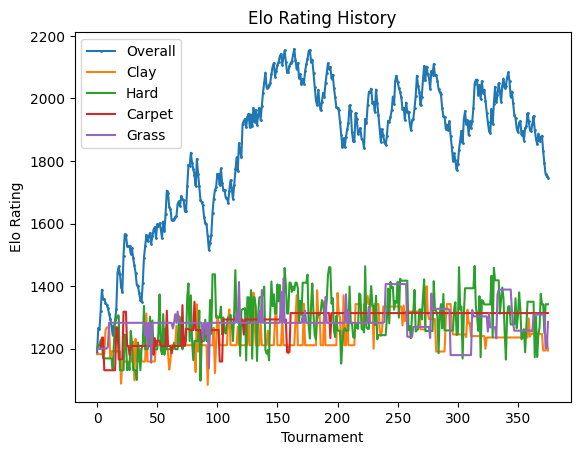

In [73]:
import matplotlib.pyplot as plt

player_id = 104745 # Nadal
player_id = 103819 # Federer
elo_history = list(all_tours.players[player_id].elo_history.values())
elo_clay_history = list(all_tours.players[player_id].elo_surf_history['Clay'].values())
elo_hard_history = list(all_tours.players[player_id].elo_surf_history['Hard'].values())
elo_carpet_history = list(all_tours.players[player_id].elo_surf_history['Carpet'].values())
elo_grass_history = list(all_tours.players[player_id].elo_surf_history['Grass'].values())

plt.plot(elo_history, label='Overall', marker='o', markersize=1)
plt.plot(elo_clay_history, label='Clay')
plt.plot(elo_hard_history, label='Hard')
plt.plot(elo_carpet_history, label='Carpet')
plt.plot(elo_grass_history, label='Grass')

plt.xlabel('Tournament')
plt.ylabel('Elo Rating')
plt.title('Elo Rating History')
plt.legend()
plt.show()


In [60]:
len(list(all_tours.ranking.values()))

7527

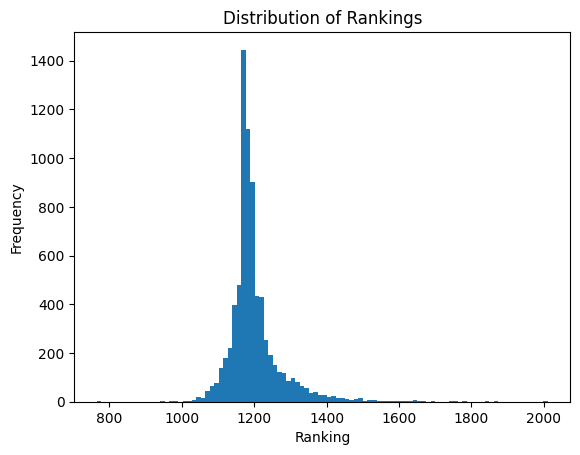

In [61]:
list(all_tours.ranking.values())
import matplotlib.pyplot as plt

ranking_values = list(all_tours.ranking.values())

plt.hist(ranking_values, bins=100)
plt.xlabel('Ranking')
plt.ylabel('Frequency')
plt.title('Distribution of Rankings')
plt.show()


In [76]:
save_ranking(all_tours, 'atp')

In [1]:
import pandas as pd

data = {
    'Column1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Column2': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Column3': [True, False, True, False, True, False, True, False, True, False],
    'Column4': [1.1, 2.2, 3.3, 4.4, 5.5, 6.6, 7.7, 8.8, 9.9, 10.10]
}

df = pd.DataFrame(data)
df

,Column1,Column2,Column3,Column4
0,1,A,True,1.1
1,2,B,False,2.2
2,3,C,True,3.3
3,4,D,False,4.4
4,5,E,True,5.5
5,6,F,False,6.6
6,7,G,True,7.7
7,8,H,False,8.8
8,9,I,True,9.9
9,10,J,False,10.1


In [4]:
df.loc[df['Column1'] == 4, 'Column2'] = 'C'
df


,Column1,Column2,Column3,Column4
0,1,A,True,1.1
1,2,B,False,2.2
2,3,C,True,3.3
3,4,C,False,4.4
4,5,E,True,5.5
5,6,F,False,6.6
6,7,G,True,7.7
7,8,H,False,8.8
8,9,I,True,9.9
9,10,J,False,10.1


In [3]:
df

,Column1,Column2,Column3,Column4
0,1,A,True,1.1
1,2,B,False,2.2
2,3,C,True,3.3
3,4,D,False,4.4
4,5,E,True,5.5
5,6,F,False,6.6
6,7,G,True,7.7
7,8,H,False,8.8
8,9,I,True,9.9
9,10,J,False,10.1


# blablablabalbal



In [3]:
import pandas as pd

import streamlit as st
from time import time
from datetime import datetime
import matplotlib.pyplot as plt

In [4]:
matches_df = pd.read_csv('web/web_data/clean_atp_matches.csv')
players_df = pd.read_csv('web/web_data/clean_atp_players.csv')
assert matches_df.isna().sum().sum() == 0, f'nan values in matches\n{matches_df.isna().sum()}'
assert players_df.isna().sum().sum() == 0, f'nan values in players\n{players_df.isna().sum()}'

In [5]:
k = 24
ksi = 400
s = 'delta'
initial_elo = 1500
min_games = 30

In [6]:
def simulate_tour(tour_df:pd.DataFrame, players_df:pd.DataFrame, k, ksi, s, initial_elo, min_games): 
    assert tour_df.isna().sum().sum() == 0, f'nan values in tour_df\n{tour_df.isna().sum()}'

    players_dic = {player_id: {
            'player_id': player_id, 
            'elo_rating': initial_elo, 
            'elo_clay_rating': initial_elo, 
            'elo_hard_rating': initial_elo, 
            'elo_grass_rating': initial_elo, 
            'elo_carpet_rating': initial_elo, 
            'elo_unknown_rating': initial_elo,
            'n_games': 0,
            'last_game': None
        } for player_id in players_df['player_id']}

    elo_history_list = []

    year = ''
    for _, m in tour_df.iterrows():
        
        if year != m['match_year']:
            # placeholder.write(f'    Simulating year {m['match_year']}...')
            year = m['match_year']

        # Update elo ratings
        match s:
            case 'delta':
                Sw = 1
                Sl = 0

            case 'thirds': 
                if m['best_of'] != m['num_sets'] or m['best_of'] == 1:
                    Sw = 1
                    Sl = 0
                else: 
                    Sw = 2/3
                    Sl = 1/3

        
        # Algorisme per calcular elo-ratings
        winner_id = m['winner_id']
        loser_id = m['loser_id']
        elo_surface = f'elo_{m['surface'].lower()}_rating'
        match_date = m['tourney_date']
        surface = m['surface']

        old_wr =  players_dic[winner_id]['elo_rating']
        old_lr = players_dic[loser_id]['elo_rating']
        # Surface
        old_slr = players_dic[winner_id][elo_surface]
        old_swr = players_dic[loser_id][elo_surface]

        mu_w = 1 / (1 + pow(10, -(old_wr - old_lr)/ksi))
        mu_l = 1 / (1 + pow(10, -(old_lr - old_wr)/ksi))
        # Surface
        mu_sw = 1 / (1 + pow(10, -(old_swr - old_slr)/ksi))
        mu_sl = 1 / (1 + pow(10, -(old_slr - old_swr)/ksi))

        # Actualitzar els valors dels elo-ratings dels jugadors. 
        winner_new_elo = old_wr + k*(Sw - mu_w)
        loser_new_elo = old_lr + k*(Sl - mu_l)
        players_dic[winner_id]['elo_rating'] = winner_new_elo
        players_dic[loser_id]['elo_rating'] = loser_new_elo
        # Surface
        players_dic[winner_id][elo_surface] = old_swr + k*(Sw - mu_sw)
        players_dic[loser_id][elo_surface] = old_slr + k*(Sl - mu_sl)

        players_dic[loser_id]['n_games'] += 1
        players_dic[loser_id]['last_game'] = match_date
        players_dic[winner_id]['n_games'] += 1
        players_dic[winner_id]['last_game'] = match_date

        # Històric
        winner_history = {
            'player_id': winner_id,
            'date': match_date,
            'surface': surface,
            'elo_rating': winner_new_elo
        }
        loser_history = {
            'player_id': loser_id,
            'date': match_date,
            'surface': surface,
            'elo_rating': loser_new_elo
        }

        elo_history_list.append(winner_history)
        elo_history_list.append(loser_history)


    players_simulated: pd.DataFrame = pd.DataFrame.from_dict(players_dic, orient='index')

    ranking: pd.DataFrame = players_df.merge(players_simulated, how='left', on='player_id')\
        .sort_values(by='elo_rating', ascending=False)\
        .reset_index(drop=True)\
        .drop(columns=['elo_unknown_rating'])\
        .round(0)\
        .rename(columns={
            'elo_rating': 'Elo Rating', 
            'elo_clay_rating': 'Clay Elo Rating', 
            'elo_hard_rating': 'Hard Elo Rating', 
            'elo_grass_rating': 'Grass Elo Rating', 
            'elo_carpet_rating': 'Carpet Elo Rating'
        })


    ranking_filtered = ranking[(ranking['n_games']>min_games) & (ranking['last_game'] > '2023-01-01')].reset_index(drop=True)

    ranking_filtered.index += 1

    elo_history_df = pd.DataFrame(elo_history_list)\
                        .astype({'date': 'datetime64[ns]'})

    return ranking_filtered, elo_history_df


In [7]:
ranking, elo_history = simulate_tour(matches_df, players_df, k, ksi, s, initial_elo, min_games)

In [8]:
ranking

,player_id,First Name,Last Name,Hand,Country,Height,Elo Rating,Clay Elo Rating,Hard Elo Rating,Grass Elo Rating,Carpet Elo Rating,n_games,last_game
1,206173,Jannik,Sinner,R,ITA,191,2160.0,1544.0,1599.0,1559.0,1500.0,353,2024-11-24
2,104925,Novak,Djokovic,R,SRB,188,2086.0,1609.0,1513.0,1526.0,1545.0,1363,2024-09-14
3,207989,Carlos,Alcaraz,R,ESP,183,2020.0,1517.0,1562.0,1591.0,1500.0,265,2024-11-19
4,100644,Alexander,Zverev,R,GER,198,1953.0,1539.0,1478.0,1565.0,1500.0,663,2024-11-11
5,126203,Taylor,Fritz,R,USA,196,1915.0,1569.0,1509.0,1563.0,1500.0,476,2024-02-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,105614,Bradley,Klahn,L,USA,183,1448.0,1467.0,1529.0,1476.0,1500.0,56,2023-07-31
215,106005,Constant,Lestienne,R,FRA,180,1433.0,1464.0,1516.0,1515.0,1500.0,59,2024-08-26
216,202358,Chun Hsin,Tseng,R,TPE,175,1422.0,1524.0,1517.0,1502.0,1500.0,32,2024-09-14
217,105332,Benoit,Paire,R,FRA,196,1415.0,1525.0,1495.0,1511.0,1500.0,541,2024-07-15


In [9]:
elo_history

,player_id,date,surface,elo_rating
0,100106,1970-07-06,Grass,1512.000000
1,125672,1970-07-06,Grass,1488.000000
2,209533,1970-07-06,Grass,1512.000000
3,209675,1970-07-06,Grass,1488.000000
4,100100,1970-07-06,Grass,1512.000000
...,...,...,...,...
374903,144775,2024-02-02,Hard,1484.641879
374904,122533,2024-02-02,Hard,1544.740755
374905,144748,2024-02-02,Hard,1478.031199
374906,202475,2024-02-02,Hard,1492.606687


In [10]:
elo_history.to_csv('web/web_data/initial_elo_history.csv')
ranking.to_csv('web/web_data/initial_ranking.csv')

In [11]:
initial_ranking = pd.read_csv('web/web_data/initial_ranking.csv')
initial_elo_history = pd.read_csv('web/web_data/initial_elo_history.csv')
ranking = initial_ranking
elo_history = initial_elo_history